# 📊 Tarea paso a paso: Gráficos Pair Plot

**¡ATENCIÓN! Lee esto antes de empezar:**
Esta tarea está diseñada paso a paso para que afiances los conceptos vistos en clase sobre los `Pair Plots`. Su objetivo es que practiques cómo realizar un análisis exploratorio multivariante visual de manera ultrarrápida.

⚠️ **Nota importante sobre la Inteligencia Artificial:**
Es tentador copiar y pegar el enunciado de estos ejercicios en ChatGPT o Claude para que te den la solución... **Hacer eso perjudicará gravemente tu aprendizaje. (CODEA UN POCO QUE TE ENTERES QUE HACES)**. La única forma de asimilar la sintaxis de las herramientas de visualización es escribiéndolas. **Usa tu cerebro, actúa paso a paso, equivócate, lee la documentación de Seaborn, busca tu fallo y ¡aprende de él!**

## 📁 Preparación y Datos

Para esta tarea vamos a utilizar un clásico de Kaggle y de la minería de datos en general: el dataset **"Iris Species"**.
Es el conjunto de datos por excelencia para hacer un `Pair Plot` porque cuenta con 4 variables numéricas relacionadas con las medidas de los pétalos y sépalos de 3 especies distintas de flores.

1. Descarga el dataset de Kaggle: [Iris Species](https://www.kaggle.com/datasets/uciml/iris)
2. Guarda el archivo `Iris.csv` en la carpeta `data/` de tu proyecto.
3. En la siguiente celda, importa las librerías necesarias (`pandas`, `matplotlib.pyplot`, `seaborn`) y carga el CSV en un DataFrame llamado `df`. (Ojo, puede que el CSV tenga una columna de ID que no aporte utilidad estadística, si es así, elimínala).

In [1]:
# Importamos pandas para trabajar con el dataset
import pandas as pd
# Importamos seaborn para crear los gráficos
import seaborn as sns
# Importamos matplotlib para apoyar la visualización
import matplotlib.pyplot as plt

# Configuramos un estilo sencillo para seaborn
sns.set_style("whitegrid")

# Cargamos el archivo CSV de iris
df = pd.read_csv("data/Iris.csv")

# Eliminamos la columna Id porque no aporta valor estadístico al gráfico
df = df.drop(columns=["Id"])

# Mostramos las primeras filas para revisar los datos
df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 🛠️ Paso 1: Pair Plot Básico (La Matriz Completa)

**Objetivo:** Generar una matriz de dispersión "cruda" que cruce todas tus variables numéricas de una sola vez.

**Instrucciones:**
1. Llama a la función `seaborn.pairplot` pasándole simplemente tu dataframe (`df`).
2. ¡Y ya está! Observa el resultado. Fíjate en cómo en la diagonal aparecen histogramas y en el resto de la matriz gráficos de dispersión (scatter).

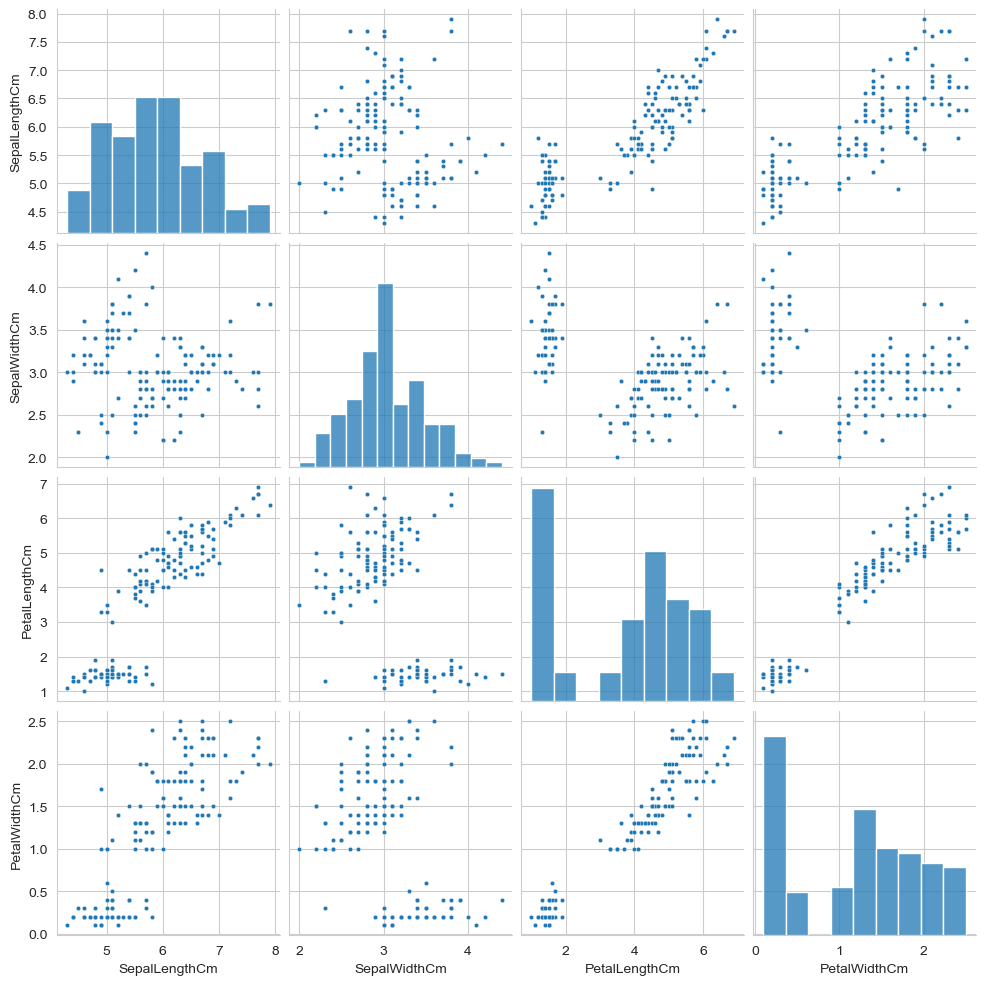

In [ ]:
# Creamos un pair plot básico
# Como antes, info de pairplot en la documentación de Seaborn:
#  https://seaborn.pydata.org/generated/seaborn.pairplot.html
sns.pairplot(
    data=df,
    plot_kws={
        's': 10
    }
)


## 🛠️ Paso 2: Separar por Categoría (El poder del parámetro Hue)

**Objetivo:** Entender cómo se diferencian los distintos grupos de tu dataset para cada par posible de métricas.

**Instrucciones:**
1. Repita el mismo gráfico, pero ahora añade el parámetro `hue` y asígnale la columna de las especies de flores (`Species`).
2. Fíjate en el increíble cambio: las diagonales son ahora estimaciones de densidad (KDE) superpuestas en lugar de histogramas de un solo color, y notarás claramente cómo ciertas medidas agrupan e identifican a una especie en concreto lejos de las otras dos.

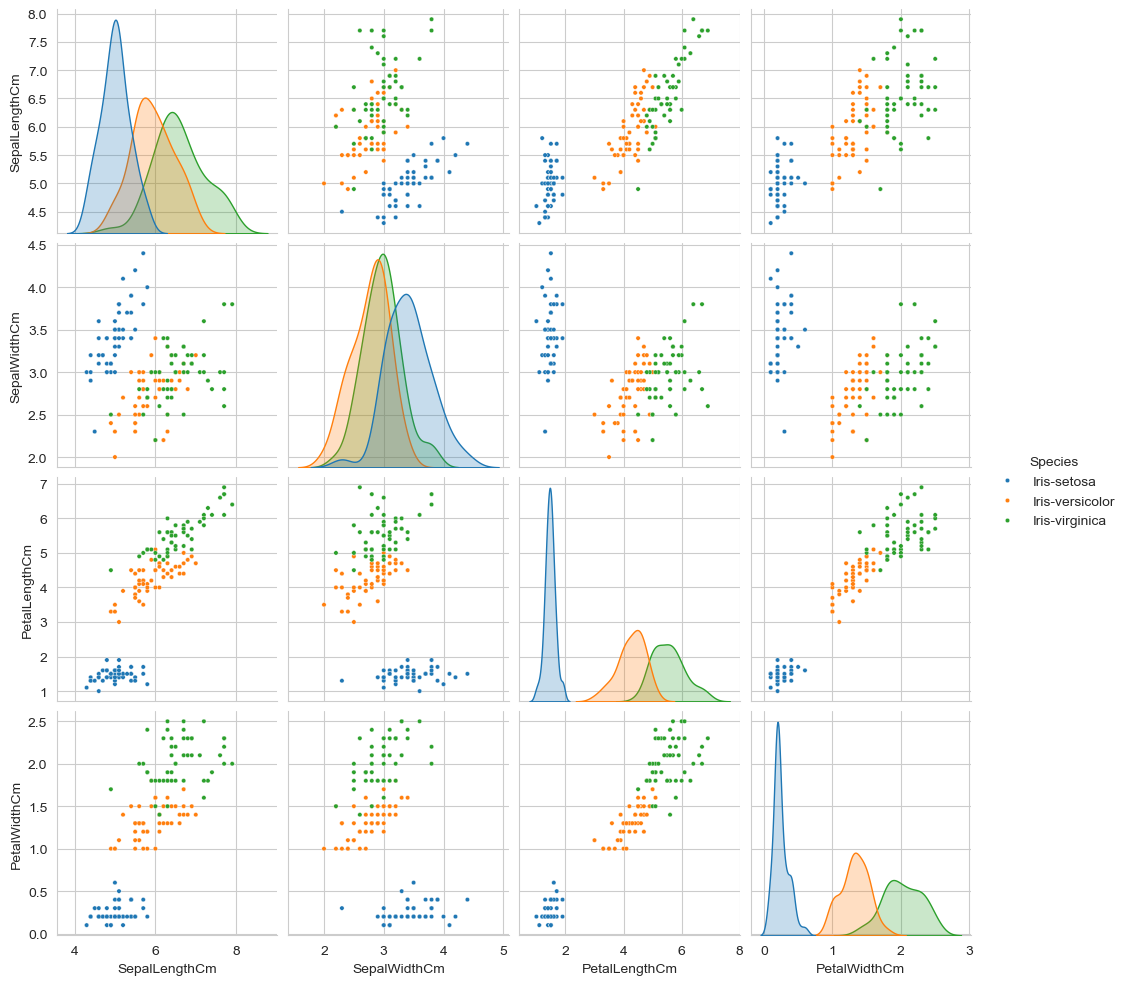

In [3]:
# Creamos un pair plot separando por especie
sns.pairplot(
    data=df,
    hue='Species',
    plot_kws={
        's': 10
    }
)


## 🛠️ Paso 3: Filtrar Columnas (Parámetro Vars)

**Objetivo:** ¿Qué pasa si tu dataset tiene 20 columnas numéricas? Generar una matriz 20x20 es ilegible y muy lento. Practiquemos cómo quedarnos solo con un subconjunto.

**Instrucciones:**
1. Vuelve a hacer el gráfico (con su `hue="Species"`).
2. Añade el parámetro `vars` y pásale una lista con los nombres exactos de solo dos columnas: por ejemplo `["SepalLengthCm", "PetalLengthCm"]`.
3. Observa cómo has generado un gráfico mucho más específico (matriz 2x2).

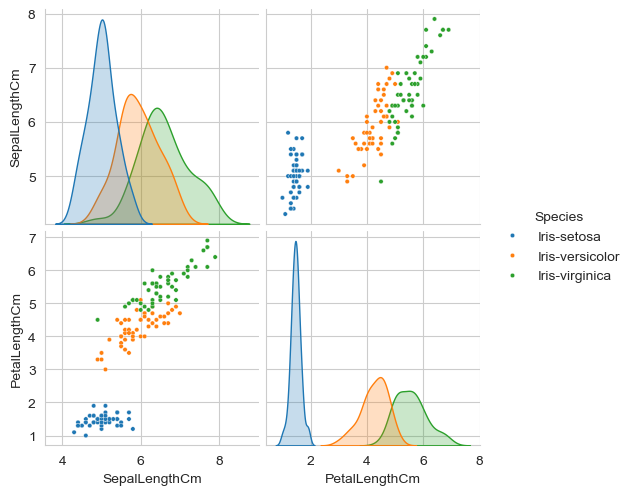

In [4]:
# Creamos un pair plot con solo dos columnas numéricas
sns.pairplot(
    data=df,
    hue='Species',
    vars=['SepalLengthCm', 'PetalLengthCm'],
    plot_kws={
        's': 10
    }
)


## 🛠️ Paso 4: Modificando las gráficas internas de la matriz

**Objetivo:** Controlar independientemente el comportamiento de la diagonal respecto al resto de la matriz.

**Instrucciones:**
1. Haz un `pairplot` del dataframe entero y con el `hue="Species"`.
2. Para cambiar el comportamiento de las gráficas de la diagonal, añade el parámetro explícito `diag_kind="hist"`. Fíjate que al haber usado `hue` esto forzará histogramas apilados en vez de líneas de densidad.
3. Personaliza la paleta de colores usando el argumento `palette` (prueba algo como `"husl"` o `"Set2"`).
4. (Opcional): Si deseas ajustar el tamaño o estilo de los puntos del scatter plot usa el argumento `plot_kws={'alpha': 0.6, 's': 40}`

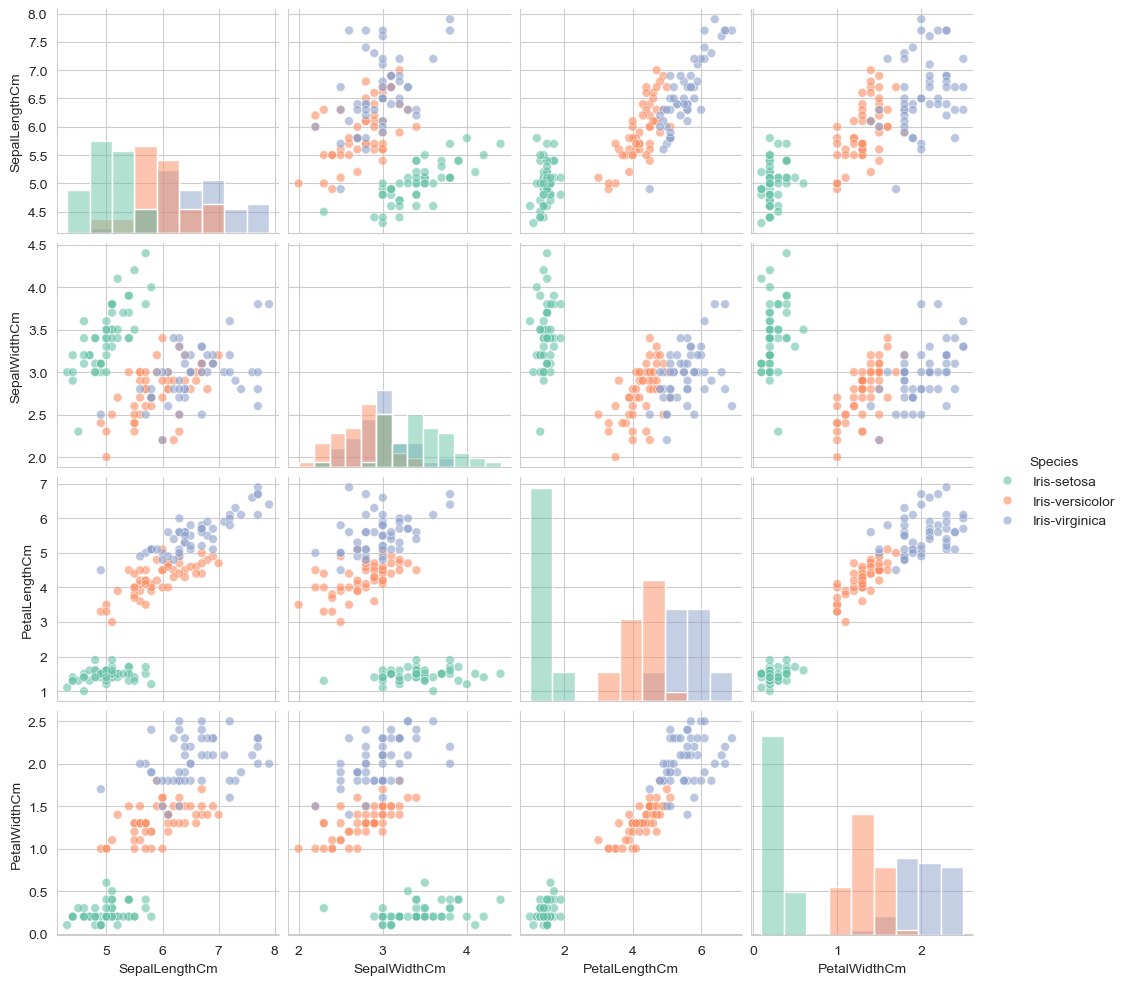

In [5]:
# Creamos un pair plot modificando la diagonal y la paleta
sns.pairplot(
    data=df,
    hue='Species',
    diag_kind='hist',
    palette='Set2',
    plot_kws={
        'alpha': 0.6,
        's': 40
    }
)


## 🌟 Reflexión Final del Alumno

**Tómate un rato para reflexionar.** 
* La **gráfica Pair Plot** debería estar siempre en la primera libreta de cualquier Exploratory Data Analysis (EDA) que hagas en el futuro. De un simple vistazo revela colinealidad (mucha correlación entre variables) o patrones de agrupamiento evidentes (clusters).
* Recuerda una limitación importante: el coste computacional. Aplicar `sns.pairplot` a un CSV de 50 columnas con un millón de filas directamente puede dejar congelado tu Jupyter Notebook. Empieza seleccionando unas pocas columnas con el método introducido en esta tarea.

**Asegúrate de que cada celda tenga sus respectivos comentarios.**

## REFLEXIÓN FINAL
- Con los jointplots se pueden observar conclusiones interesantes. En el primer gráfico vemos muy fuerte correlación del petal lentgh - petal width. 
con las sepal variables hay más dispersión
- Segundo gráfico, Setosa es un cluster en si mismo, muy separada del resto. Versicolor y virginia se solapan, más dificil de diferenciar por los datos.
- Vemos en el tercer gráfico que Petallength y petalwidth hace que se diferencien muy bien especies. sepalwidth no aporta tanto.
- Respecto a las distribuciones - Setosa valores bajos , muy diferenciada. el resto más intermedia / alta. 